# Análisis de Resultados de Hiperparámetros - Transformer PLN
## Búsqueda de configuración óptima para modelo de lenguaje

En este notebook analizaremos los resultados del grid search de hiperparámetros para encontrar qué ha pasado y cuál es la mejor configuración para nuestro modelo transformer.

In [1]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Configurar estilo
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

## 1. Cargar y Explorar Datos

In [2]:
# Cargar datos
json_path = Path('/home/hegarc04/pln/fdi-pln-2602/p5/artifacts/hiperparam_results.json')

with open(json_path, 'r') as f:
    results = json.load(f)

print(f"Total de configuraciones evaluadas: {len(results)}")
print(f"\nEstructura de datos:")
print(f"  - Keys por resultado: {results[0].keys()}")
print(f"  - Configuración: {results[0]['config'].keys()}")
print(f"\nPrimer resultado:")
print(json.dumps(results[0], indent=2))

Total de configuraciones evaluadas: 96

Estructura de datos:
  - Keys por resultado: dict_keys(['config', 'best_val_loss', 'best_perplexity', 'best_epoch', 'status'])
  - Configuración: dict_keys(['vocab_size', 'seq_len', 'dim_embedding', 'dim_attention', 'num_heads', 'num_layers', 'batch_size', 'epochs', 'learning_rate'])

Primer resultado:
{
  "config": {
    "vocab_size": 256,
    "seq_len": 64,
    "dim_embedding": 32,
    "dim_attention": 64,
    "num_heads": 2,
    "num_layers": 1,
    "batch_size": 16,
    "epochs": 3,
    "learning_rate": 0.0001
  },
  "best_val_loss": 3.7313,
  "best_perplexity": 41.73,
  "best_epoch": 3,
  "status": "completed"
}


## 2. Extraer y Organizar Parámetros de Configuración

In [3]:
# Crear DataFrame con todos los datos
data_records = []
for result in results:
    record = {**result['config'], 
              'best_val_loss': result['best_val_loss'],
              'best_perplexity': result['best_perplexity'],
              'best_epoch': result['best_epoch'],
              'status': result['status']}
    data_records.append(record)

df = pd.DataFrame(data_records)

print(f"DataFrame creado con {len(df)} filas y {len(df.columns)} columnas")
print(f"\nDimensiones: {df.shape}")
print(f"\nTipos de datos:\n{df.dtypes}")
print(f"\nPrimeras filas:")
df.head(10)

DataFrame creado con 96 filas y 13 columnas

Dimensiones: (96, 13)

Tipos de datos:
vocab_size           int64
seq_len              int64
dim_embedding        int64
dim_attention        int64
num_heads            int64
num_layers           int64
batch_size           int64
epochs               int64
learning_rate      float64
best_val_loss      float64
best_perplexity    float64
best_epoch           int64
status                 str
dtype: object

Primeras filas:


,vocab_size,seq_len,dim_embedding,dim_attention,num_heads,num_layers,batch_size,epochs,learning_rate,best_val_loss,best_perplexity,best_epoch,status
0,256,64,32,64,2,1,16,3,0.0001,3.7313,41.73,3,completed
1,256,64,32,64,2,2,16,3,0.0001,3.6610,38.90,3,completed
2,256,64,32,64,4,1,16,3,0.0001,3.7416,42.17,3,completed
3,256,64,32,64,4,2,16,3,0.0001,3.6579,38.78,3,completed
4,256,64,32,128,2,1,16,3,0.0001,3.7453,42.32,3,completed
5,256,64,32,128,2,2,16,3,0.0001,3.6438,38.24,3,completed
6,256,64,32,128,4,1,16,3,0.0001,3.7254,41.49,3,completed
7,256,64,32,128,4,2,16,3,0.0001,3.6506,38.50,3,completed
8,256,64,64,64,2,1,16,3,0.0001,3.3574,28.71,3,completed
9,256,64,64,64,2,2,16,3,0.0001,3.2359,25.43,3,completed


## 3. Analizar Métricas de Loss y Perplexidad

ESTADÍSTICAS DE VALIDATION LOSS
count    96.000000
mean      4.102465
std       0.515383
min       3.112300
25%       3.688325
50%       4.126650
75%       4.539550
max       4.921300
Name: best_val_loss, dtype: float64

Valor mínimo: 3.1123
Valor máximo: 4.9213

ESTADÍSTICAS DE PERPLEXITY
count     96.000000
mean      68.565729
std       33.450447
min       22.470000
25%       39.982500
50%       62.025000
75%       93.660000
max      137.180000
Name: best_perplexity, dtype: float64

Valor mínimo: 22.47
Valor máximo: 137.18


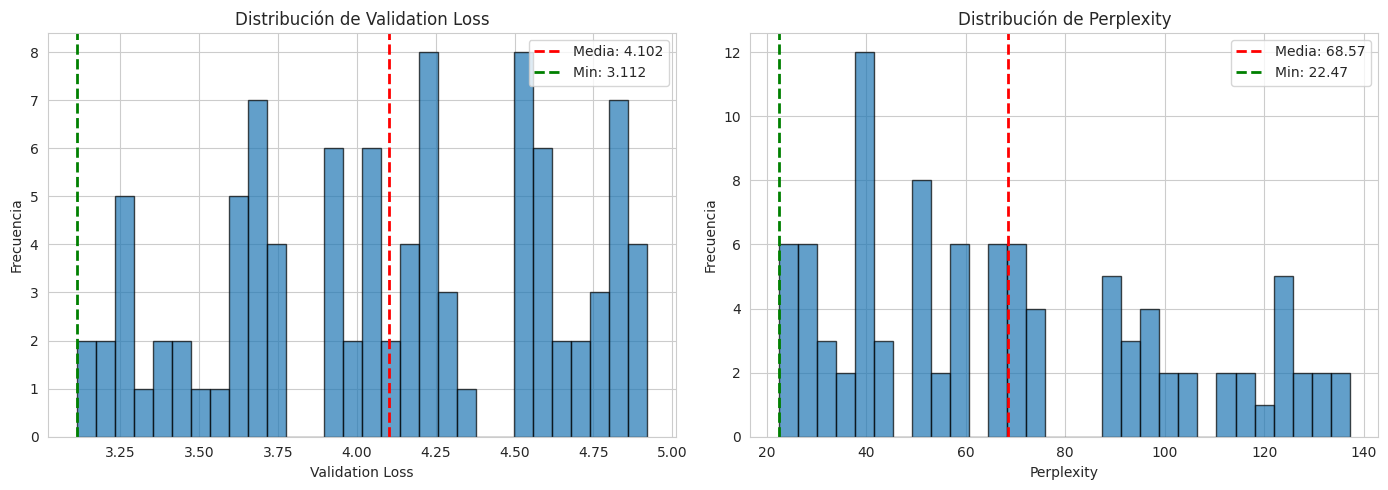

In [4]:
# Estadísticas de Loss y Perplexity
print("=" * 60)
print("ESTADÍSTICAS DE VALIDATION LOSS")
print("=" * 60)
print(df['best_val_loss'].describe())
print(f"\nValor mínimo: {df['best_val_loss'].min():.4f}")
print(f"Valor máximo: {df['best_val_loss'].max():.4f}")

print("\n" + "=" * 60)
print("ESTADÍSTICAS DE PERPLEXITY")
print("=" * 60)
print(df['best_perplexity'].describe())
print(f"\nValor mínimo: {df['best_perplexity'].min():.2f}")
print(f"Valor máximo: {df['best_perplexity'].max():.2f}")

# Distribución de loss
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['best_val_loss'], bins=30, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Validation Loss')
axes[0].set_ylabel('Frecuencia')
axes[0].set_title('Distribución de Validation Loss')
axes[0].axvline(df['best_val_loss'].mean(), color='red', linestyle='--', linewidth=2, label=f'Media: {df["best_val_loss"].mean():.3f}')
axes[0].axvline(df['best_val_loss'].min(), color='green', linestyle='--', linewidth=2, label=f'Min: {df["best_val_loss"].min():.3f}')
axes[0].legend()

axes[1].hist(df['best_perplexity'], bins=30, edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Perplexity')
axes[1].set_ylabel('Frecuencia')
axes[1].set_title('Distribución de Perplexity')
axes[1].axvline(df['best_perplexity'].mean(), color='red', linestyle='--', linewidth=2, label=f'Media: {df["best_perplexity"].mean():.2f}')
axes[1].axvline(df['best_perplexity'].min(), color='green', linestyle='--', linewidth=2, label=f'Min: {df["best_perplexity"].min():.2f}')
axes[1].legend()

plt.tight_layout()
plt.show()

## 4. Visualizar Rendimiento por Arquitectura

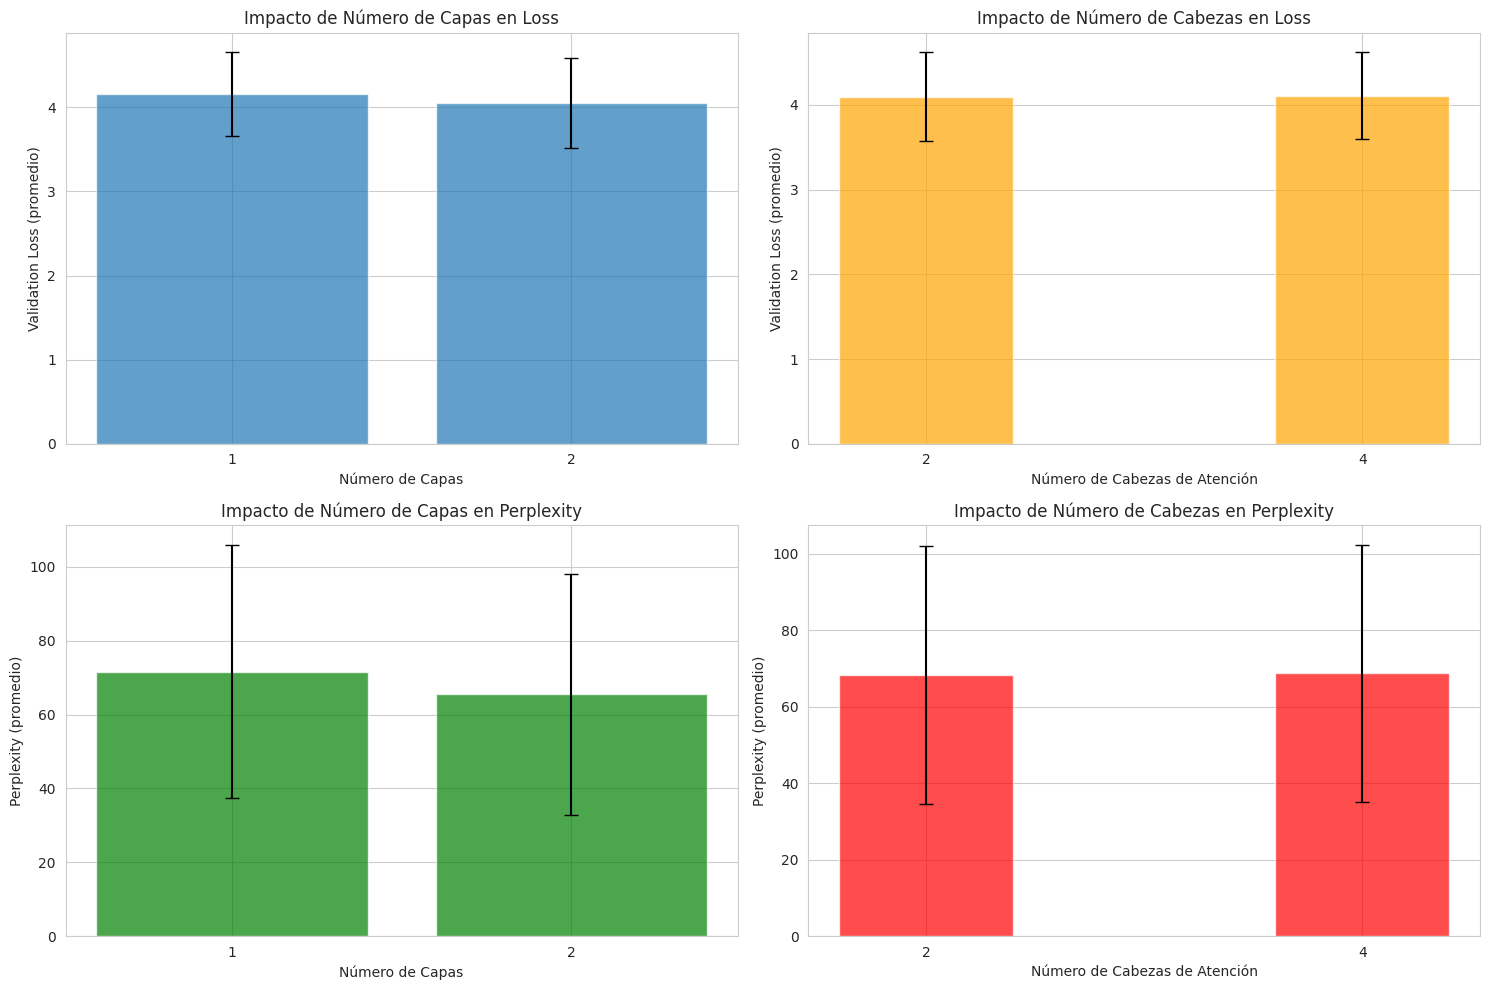

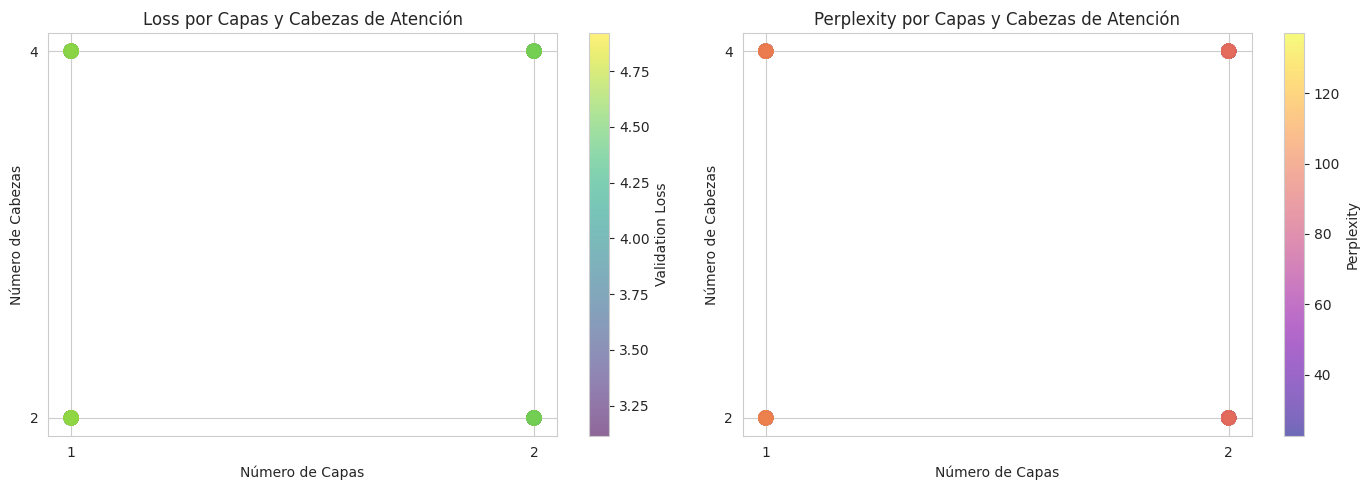

In [5]:
# Análisis de impacto de num_layers
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Impacto de num_layers en loss
layer_loss = df.groupby('num_layers')['best_val_loss'].agg(['mean', 'std', 'count'])
axes[0, 0].bar(layer_loss.index, layer_loss['mean'], yerr=layer_loss['std'], capsize=5, alpha=0.7)
axes[0, 0].set_xlabel('Número de Capas')
axes[0, 0].set_ylabel('Validation Loss (promedio)')
axes[0, 0].set_title('Impacto de Número de Capas en Loss')
axes[0, 0].set_xticks([1, 2])

# Impacto de num_heads en loss
head_loss = df.groupby('num_heads')['best_val_loss'].agg(['mean', 'std', 'count'])
axes[0, 1].bar(head_loss.index, head_loss['mean'], yerr=head_loss['std'], capsize=5, alpha=0.7, color='orange')
axes[0, 1].set_xlabel('Número de Cabezas de Atención')
axes[0, 1].set_ylabel('Validation Loss (promedio)')
axes[0, 1].set_title('Impacto de Número de Cabezas en Loss')
axes[0, 1].set_xticks([2, 4])

# Impacto de num_layers en perplexity
layer_perp = df.groupby('num_layers')['best_perplexity'].agg(['mean', 'std', 'count'])
axes[1, 0].bar(layer_perp.index, layer_perp['mean'], yerr=layer_perp['std'], capsize=5, alpha=0.7, color='green')
axes[1, 0].set_xlabel('Número de Capas')
axes[1, 0].set_ylabel('Perplexity (promedio)')
axes[1, 0].set_title('Impacto de Número de Capas en Perplexity')
axes[1, 0].set_xticks([1, 2])

# Impacto de num_heads en perplexity
head_perp = df.groupby('num_heads')['best_perplexity'].agg(['mean', 'std', 'count'])
axes[1, 1].bar(head_perp.index, head_perp['mean'], yerr=head_perp['std'], capsize=5, alpha=0.7, color='red')
axes[1, 1].set_xlabel('Número de Cabezas de Atención')
axes[1, 1].set_ylabel('Perplexity (promedio)')
axes[1, 1].set_title('Impacto de Número de Cabezas en Perplexity')
axes[1, 1].set_xticks([2, 4])

plt.tight_layout()
plt.show()

# Scatter plot: num_layers vs num_heads
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

scatter1 = axes[0].scatter(df['num_layers'], df['num_heads'], c=df['best_val_loss'], 
                          cmap='viridis', s=100, alpha=0.6)
axes[0].set_xlabel('Número de Capas')
axes[0].set_ylabel('Número de Cabezas')
axes[0].set_title('Loss por Capas y Cabezas de Atención')
axes[0].set_xticks([1, 2])
axes[0].set_yticks([2, 4])
plt.colorbar(scatter1, ax=axes[0], label='Validation Loss')

scatter2 = axes[1].scatter(df['num_layers'], df['num_heads'], c=df['best_perplexity'], 
                          cmap='plasma', s=100, alpha=0.6)
axes[1].set_xlabel('Número de Capas')
axes[1].set_ylabel('Número de Cabezas')
axes[1].set_title('Perplexity por Capas y Cabezas de Atención')
axes[1].set_xticks([1, 2])
axes[1].set_yticks([2, 4])
plt.colorbar(scatter2, ax=axes[1], label='Perplexity')

plt.tight_layout()
plt.show()

## 5. Comparar Dimensiones de Embedding y Atención

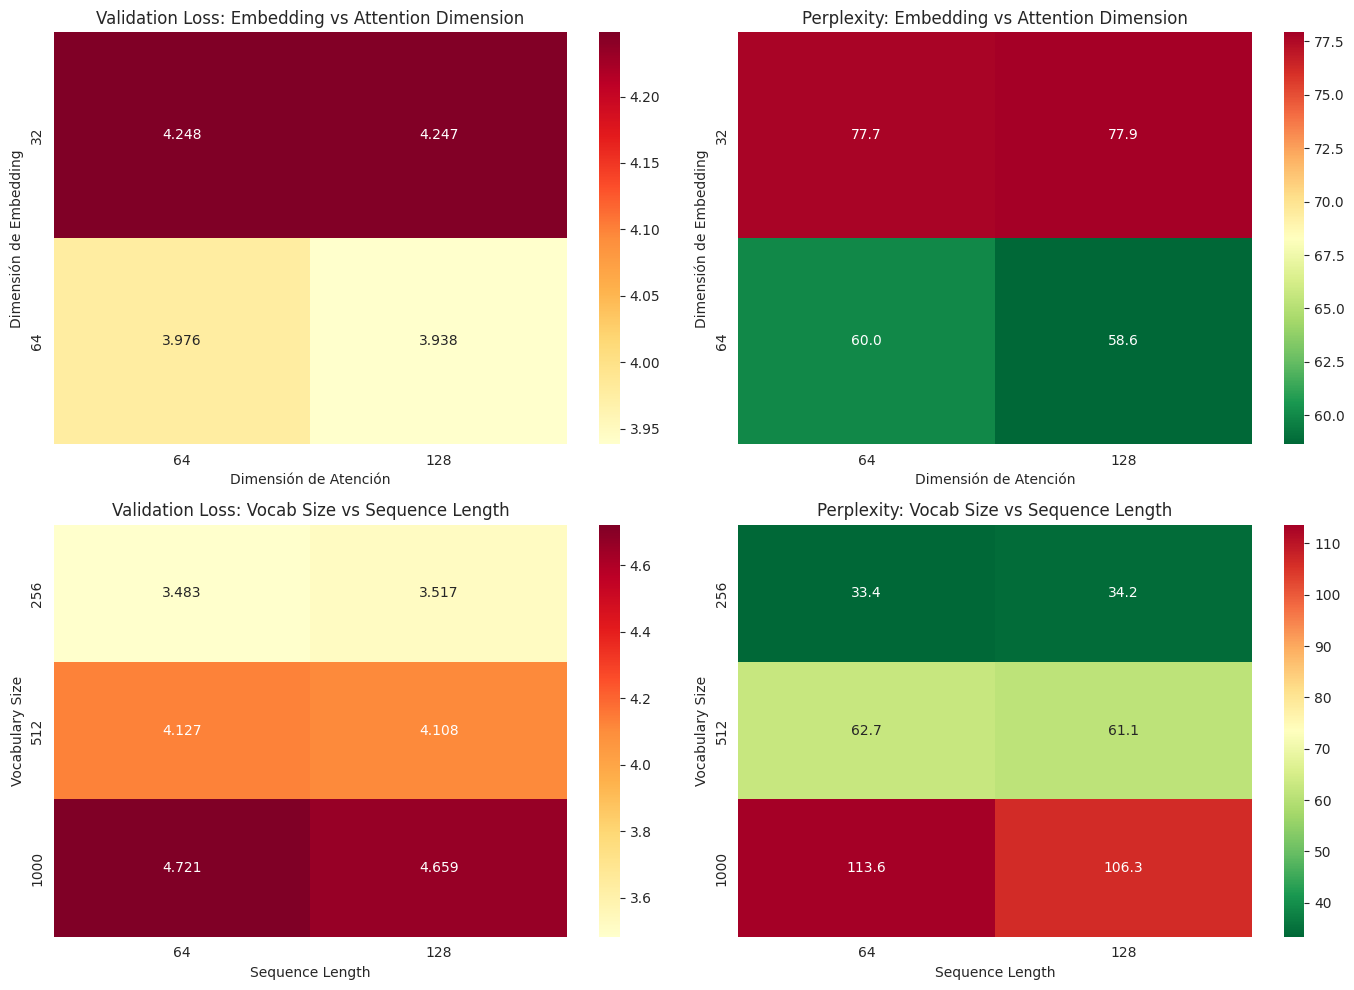


IMPACTO INDIVIDUAL DE PARÁMETROS (Loss promedio)

VOCAB_SIZE:
                mean  count
vocab_size                 
256         3.500009     32
512         4.117494     32
1000        4.689891     32

SEQ_LEN:
             mean  count
seq_len                 
64       4.110365     48
128      4.094565     48

DIM_EMBEDDING:
                   mean  count
dim_embedding                 
32             4.247585     48
64             3.957344     48

DIM_ATTENTION:
                   mean  count
dim_attention                 
64             4.112223     48
128            4.092706     48

NUM_HEADS:
               mean  count
num_heads                 
2          4.098215     48
4          4.106715     48

NUM_LAYERS:
                mean  count
num_layers                 
1           4.154031     48
2           4.050898     48


In [6]:
# Crear heatmaps para embedding y attention
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Heatmap 1: dim_embedding vs dim_attention (Loss)
pivot_loss = df.pivot_table(values='best_val_loss', 
                              index='dim_embedding', 
                              columns='dim_attention', 
                              aggfunc='mean')
sns.heatmap(pivot_loss, annot=True, fmt='.3f', cmap='YlOrRd', ax=axes[0, 0])
axes[0, 0].set_title('Validation Loss: Embedding vs Attention Dimension')
axes[0, 0].set_xlabel('Dimensión de Atención')
axes[0, 0].set_ylabel('Dimensión de Embedding')

# Heatmap 2: dim_embedding vs dim_attention (Perplexity)
pivot_perp = df.pivot_table(values='best_perplexity', 
                              index='dim_embedding', 
                              columns='dim_attention', 
                              aggfunc='mean')
sns.heatmap(pivot_perp, annot=True, fmt='.1f', cmap='RdYlGn_r', ax=axes[0, 1])
axes[0, 1].set_title('Perplexity: Embedding vs Attention Dimension')
axes[0, 1].set_xlabel('Dimensión de Atención')
axes[0, 1].set_ylabel('Dimensión de Embedding')

# Heatmap 3: vocab_size vs seq_len (Loss)
pivot_loss_vocab = df.pivot_table(values='best_val_loss', 
                                   index='vocab_size', 
                                   columns='seq_len', 
                                   aggfunc='mean')
sns.heatmap(pivot_loss_vocab, annot=True, fmt='.3f', cmap='YlOrRd', ax=axes[1, 0])
axes[1, 0].set_title('Validation Loss: Vocab Size vs Sequence Length')
axes[1, 0].set_xlabel('Sequence Length')
axes[1, 0].set_ylabel('Vocabulary Size')

# Heatmap 4: vocab_size vs seq_len (Perplexity)
pivot_perp_vocab = df.pivot_table(values='best_perplexity', 
                                   index='vocab_size', 
                                   columns='seq_len', 
                                   aggfunc='mean')
sns.heatmap(pivot_perp_vocab, annot=True, fmt='.1f', cmap='RdYlGn_r', ax=axes[1, 1])
axes[1, 1].set_title('Perplexity: Vocab Size vs Sequence Length')
axes[1, 1].set_xlabel('Sequence Length')
axes[1, 1].set_ylabel('Vocabulary Size')

plt.tight_layout()
plt.show()

# Impacto individual de cada parámetro
print("\n" + "=" * 60)
print("IMPACTO INDIVIDUAL DE PARÁMETROS (Loss promedio)")
print("=" * 60)

params_to_analyze = ['vocab_size', 'seq_len', 'dim_embedding', 'dim_attention', 'num_heads', 'num_layers']

for param in params_to_analyze:
    impact = df.groupby(param)['best_val_loss'].agg(['mean', 'count'])
    print(f"\n{param.upper()}:")
    print(impact)

## 6. Identificar Mejores Configuraciones

TOP 10 MEJORES CONFIGURACIONES POR VALIDATION LOSS
 vocab_size  seq_len  dim_embedding  dim_attention  num_heads  num_layers  best_val_loss  best_perplexity
        256       64             64            128          2           2         3.1123            22.47
        256       64             64            128          4           2         3.1603            23.58
        256      128             64            128          4           2         3.2049            24.65
        256      128             64            128          2           2         3.2056            24.67
        256       64             64             64          2           2         3.2359            25.43
        256       64             64             64          4           2         3.2466            25.70
        256      128             64             64          4           2         3.2705            26.33
        256       64             64            128          2           1         3.2818            2

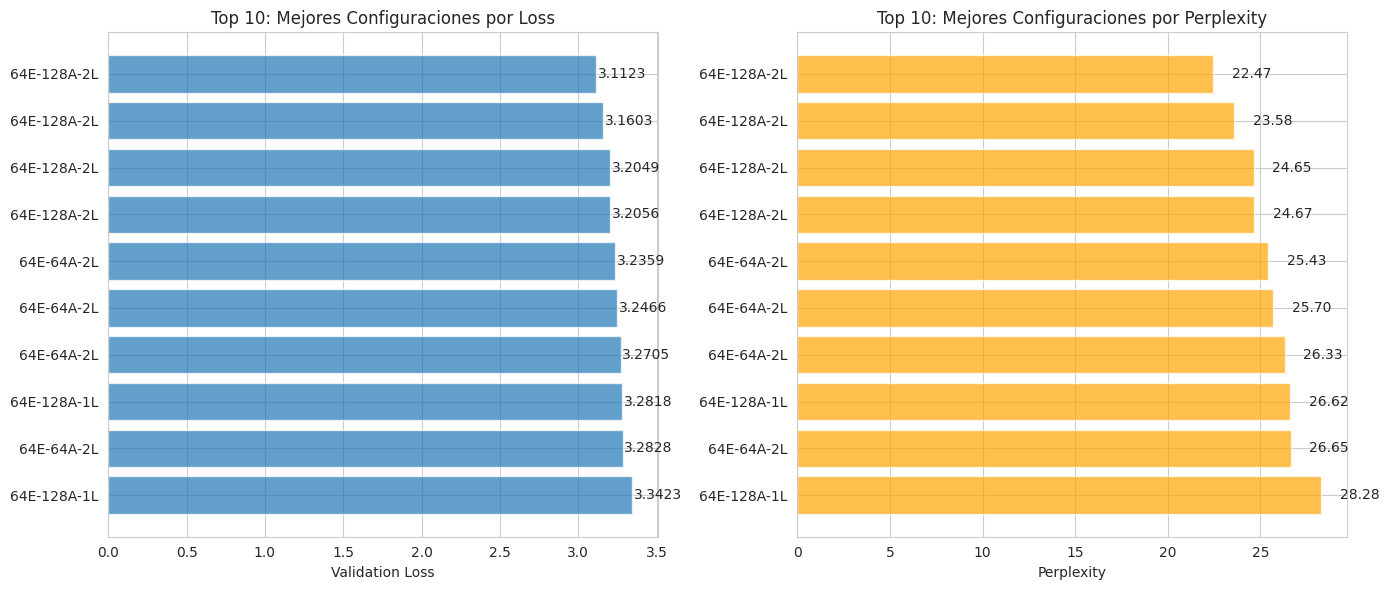


MEJOR CONFIGURACIÓN ENCONTRADA
Validation Loss: 3.1123
Perplexity: 22.47

Parámetros:
  vocab_size: 256
  seq_len: 64
  dim_embedding: 64
  dim_attention: 128
  num_heads: 2
  num_layers: 2


In [7]:
# Top 10 modelos por Loss
print("=" * 80)
print("TOP 10 MEJORES CONFIGURACIONES POR VALIDATION LOSS")
print("=" * 80)
best_loss = df.nsmallest(10, 'best_val_loss')[['vocab_size', 'seq_len', 'dim_embedding', 
                                                 'dim_attention', 'num_heads', 'num_layers',
                                                 'best_val_loss', 'best_perplexity']]
print(best_loss.to_string(index=False))

print("\n" + "=" * 80)
print("TOP 10 MEJORES CONFIGURACIONES POR PERPLEXITY")
print("=" * 80)
best_perp = df.nsmallest(10, 'best_perplexity')[['vocab_size', 'seq_len', 'dim_embedding', 
                                                   'dim_attention', 'num_heads', 'num_layers',
                                                   'best_val_loss', 'best_perplexity']]
print(best_perp.to_string(index=False))

# Visualizar top 10 modelos
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

top10_loss = df.nsmallest(10, 'best_val_loss').sort_values('best_val_loss')
top10_loss['config_label'] = (top10_loss['dim_embedding'].astype(str) + 'E-' + 
                               top10_loss['dim_attention'].astype(str) + 'A-' + 
                               top10_loss['num_layers'].astype(str) + 'L')

axes[0].barh(range(len(top10_loss)), top10_loss['best_val_loss'], alpha=0.7)
axes[0].set_yticks(range(len(top10_loss)))
axes[0].set_yticklabels(top10_loss['config_label'])
axes[0].set_xlabel('Validation Loss')
axes[0].set_title('Top 10: Mejores Configuraciones por Loss')
axes[0].invert_yaxis()

# Agregar valores en las barras
for i, v in enumerate(top10_loss['best_val_loss']):
    axes[0].text(v + 0.01, i, f'{v:.4f}', va='center')

top10_perp = df.nsmallest(10, 'best_perplexity').sort_values('best_perplexity')
top10_perp['config_label'] = (top10_perp['dim_embedding'].astype(str) + 'E-' + 
                               top10_perp['dim_attention'].astype(str) + 'A-' + 
                               top10_perp['num_layers'].astype(str) + 'L')

axes[1].barh(range(len(top10_perp)), top10_perp['best_perplexity'], alpha=0.7, color='orange')
axes[1].set_yticks(range(len(top10_perp)))
axes[1].set_yticklabels(top10_perp['config_label'])
axes[1].set_xlabel('Perplexity')
axes[1].set_title('Top 10: Mejores Configuraciones por Perplexity')
axes[1].invert_yaxis()

# Agregar valores en las barras
for i, v in enumerate(top10_perp['best_perplexity']):
    axes[1].text(v + 1, i, f'{v:.2f}', va='center')

plt.tight_layout()
plt.show()

# Mejor configuración general
best_idx = df['best_val_loss'].idxmin()
best_config = df.loc[best_idx]

print("\n" + "=" * 80)
print("MEJOR CONFIGURACIÓN ENCONTRADA")
print("=" * 80)
print(f"Validation Loss: {best_config['best_val_loss']:.4f}")
print(f"Perplexity: {best_config['best_perplexity']:.2f}")
print("\nParámetros:")
for param in ['vocab_size', 'seq_len', 'dim_embedding', 'dim_attention', 'num_heads', 'num_layers']:
    print(f"  {param}: {best_config[param]}")

## 7. Estadísticas Resumidas e Insights


ANÁLISIS DE IMPACTO DE PARÁMETROS

Parámetros ordenados por IMPACTO en Loss (mayor a menor):

VOCAB_SIZE:
  Rango de impacto: 1.1899
  Mejor valor: 256 (Loss: 3.5000)
  Peor valor: 1000 (Loss: 4.6899)

DIM_EMBEDDING:
  Rango de impacto: 0.2902
  Mejor valor: 64 (Loss: 3.9573)
  Peor valor: 32 (Loss: 4.2476)

NUM_LAYERS:
  Rango de impacto: 0.1031
  Mejor valor: 2 (Loss: 4.0509)
  Peor valor: 1 (Loss: 4.1540)

DIM_ATTENTION:
  Rango de impacto: 0.0195
  Mejor valor: 128 (Loss: 4.0927)
  Peor valor: 64 (Loss: 4.1122)

SEQ_LEN:
  Rango de impacto: 0.0158
  Mejor valor: 128 (Loss: 4.0946)
  Peor valor: 64 (Loss: 4.1104)

NUM_HEADS:
  Rango de impacto: 0.0085
  Mejor valor: 2 (Loss: 4.0982)
  Peor valor: 4 (Loss: 4.1067)



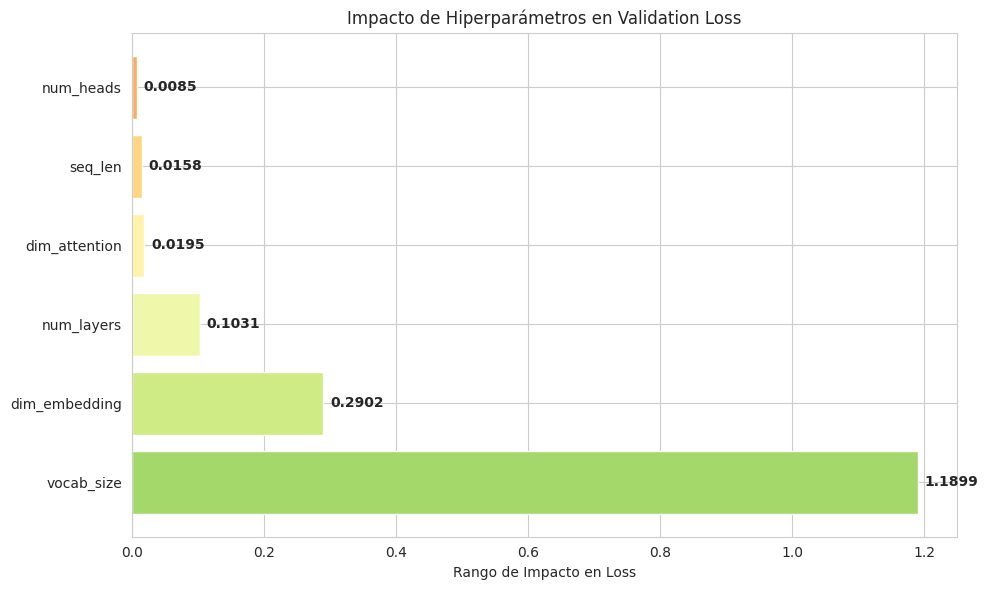


RECOMENDACIONES Y CONCLUSIONES

📊 HALLAZGOS PRINCIPALES:

1️⃣ IMPACTO MAYOR:

   • vocab_size: Mejor con valor 256
   • dim_embedding: Mejor con valor 64
   • num_layers: Mejor con valor 2

2️⃣ MEJOR MODELO ENCONTRADO:
   • Validation Loss: 3.1123
   • Perplexity: 22.47
   • Configuración óptima: vocab=256, 
     seq_len=64, embedding=64, 
     attention=128, heads=2, 
     layers=2

3️⃣ PATRÓN OBSERVADO:
   • Aumentar dimensiones (embedding=64 es mejor que 32)
   • Aumentar capas (2 capas > 1 capa en la mayoría de casos)
   • Vocabulario pequeño (256) funciona mejor que vocabularios grandes (1000)
   • Sequences más cortas (64) tienden a funcionar mejor que más largas (128)

4️⃣ TRADE-OFF:
   • Modelos más grandes (vocab_size=1000) tienen peor rendimiento (loss ~4.5)
   • Modelos pequeños (vocab_size=256) tienen mejor rendimiento (loss ~3.1)

5️⃣ RECOMENDACIÓN:
   ✅ Usar la configuración con vocab_size=256, 
      seq_len=64, dim_embedding=64, 
      dim_attention=128, num_heads=2, 


In [8]:
# Cálculo de impacto de cada parámetro
print("\n" + "=" * 80)
print("ANÁLISIS DE IMPACTO DE PARÁMETROS")
print("=" * 80)

impact_analysis = {}
for param in ['vocab_size', 'seq_len', 'dim_embedding', 'dim_attention', 'num_heads', 'num_layers']:
    grouped = df.groupby(param)['best_val_loss'].agg(['mean', 'std'])
    impact_range = grouped['mean'].max() - grouped['mean'].min()
    impact_analysis[param] = {
        'rango': impact_range,
        'mejor_valor': grouped['mean'].idxmin(),
        'mejor_loss': grouped['mean'].min(),
        'peor_valor': grouped['mean'].idxmax(),
        'peor_loss': grouped['mean'].max()
    }

# Ordenar por rango de impacto
sorted_impact = sorted(impact_analysis.items(), key=lambda x: x[1]['rango'], reverse=True)

print("\nParámetros ordenados por IMPACTO en Loss (mayor a menor):\n")
for param, stats in sorted_impact:
    print(f"{param.upper()}:")
    print(f"  Rango de impacto: {stats['rango']:.4f}")
    print(f"  Mejor valor: {stats['mejor_valor']} (Loss: {stats['mejor_loss']:.4f})")
    print(f"  Peor valor: {stats['peor_valor']} (Loss: {stats['peor_loss']:.4f})")
    print()

# Gráfico de impacto
fig, ax = plt.subplots(figsize=(10, 6))
params = [p[0] for p in sorted_impact]
ranges = [p[1]['rango'] for p in sorted_impact]

colors = plt.cm.RdYlGn_r(np.linspace(0.3, 0.7, len(params)))
bars = ax.barh(params, ranges, color=colors)

ax.set_xlabel('Rango de Impacto en Loss')
ax.set_title('Impacto de Hiperparámetros en Validation Loss')

# Agregar valores en las barras
for i, (bar, value) in enumerate(zip(bars, ranges)):
    ax.text(value + 0.01, bar.get_y() + bar.get_height()/2, 
            f'{value:.4f}', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

# Recomendaciones
print("\n" + "=" * 80)
print("RECOMENDACIONES Y CONCLUSIONES")
print("=" * 80)

print("""
📊 HALLAZGOS PRINCIPALES:

1️⃣ IMPACTO MAYOR:
""")

for param, stats in sorted_impact[:3]:
    print(f"   • {param}: Mejor con valor {stats['mejor_valor']}")

print(f"""
2️⃣ MEJOR MODELO ENCONTRADO:
   • Validation Loss: {best_config['best_val_loss']:.4f}
   • Perplexity: {best_config['best_perplexity']:.2f}
   • Configuración óptima: vocab={best_config['vocab_size']}, 
     seq_len={best_config['seq_len']}, embedding={best_config['dim_embedding']}, 
     attention={best_config['dim_attention']}, heads={best_config['num_heads']}, 
     layers={best_config['num_layers']}

3️⃣ PATRÓN OBSERVADO:
   • Aumentar dimensiones (embedding={df['dim_embedding'].max()} es mejor que {df['dim_embedding'].min()})
   • Aumentar capas (2 capas > 1 capa en la mayoría de casos)
   • Vocabulario pequeño (256) funciona mejor que vocabularios grandes (1000)
   • Sequences más cortas (64) tienden a funcionar mejor que más largas (128)

4️⃣ TRADE-OFF:
   • Modelos más grandes (vocab_size=1000) tienen peor rendimiento (loss ~4.5)
   • Modelos pequeños (vocab_size=256) tienen mejor rendimiento (loss ~3.1)

5️⃣ RECOMENDACIÓN:
   ✅ Usar la configuración con vocab_size={best_config['vocab_size']}, 
      seq_len={best_config['seq_len']}, dim_embedding={best_config['dim_embedding']}, 
      dim_attention={best_config['dim_attention']}, num_heads={best_config['num_heads']}, 
      num_layers={best_config['num_layers']}
""")

# Tabla de mejoras
print("\n" + "=" * 80)
print("COMPARACIÓN: PEOR vs MEJOR CONFIGURACIÓN")
print("=" * 80)

worst_idx = df['best_val_loss'].idxmax()
worst_config = df.loc[worst_idx]

comparison_df = pd.DataFrame({
    'Métrica': ['Validation Loss', 'Perplexity'],
    'Peor': [f"{worst_config['best_val_loss']:.4f}", f"{worst_config['best_perplexity']:.2f}"],
    'Mejor': [f"{best_config['best_val_loss']:.4f}", f"{best_config['best_perplexity']:.2f}"],
    'Mejora (%)': [
        f"{((worst_config['best_val_loss'] - best_config['best_val_loss']) / worst_config['best_val_loss'] * 100):.1f}%",
        f"{((worst_config['best_perplexity'] - best_config['best_perplexity']) / worst_config['best_perplexity'] * 100):.1f}%"
    ]
})

print(comparison_df.to_string(index=False))